In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    precision_recall_curve,
    f1_score,
    accuracy_score
)

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("datasets/dataset_phishing.csv")

df.columns = df.columns.str.strip().str.lower()
df.rename(columns={"status": "label"}, inplace=True)

df["label"] = df["label"].map({
    "legitimate": 0,
    "phishing": 1
})

In [4]:
X = df.drop(columns=["label", "url"])
y = df["label"]

X = X.replace([np.inf, -np.inf], np.nan).fillna(0)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [6]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=20,
        min_samples_split=5,
        min_samples_leaf=2,
        class_weight='balanced',
        random_state=42
    ),
    "SVM": SVC(probability=True)
}

results = {}
f1_scores = {}
acc_scores = {}


===== Logistic Regression =====
              precision    recall  f1-score   support

           0       0.93      0.94      0.94      1143
           1       0.94      0.93      0.94      1143

    accuracy                           0.94      2286
   macro avg       0.94      0.94      0.94      2286
weighted avg       0.94      0.94      0.94      2286



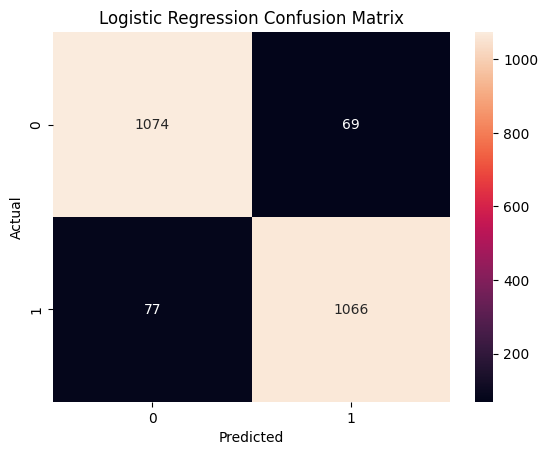


===== Random Forest =====
              precision    recall  f1-score   support

           0       0.97      0.96      0.96      1143
           1       0.96      0.97      0.96      1143

    accuracy                           0.96      2286
   macro avg       0.96      0.96      0.96      2286
weighted avg       0.96      0.96      0.96      2286



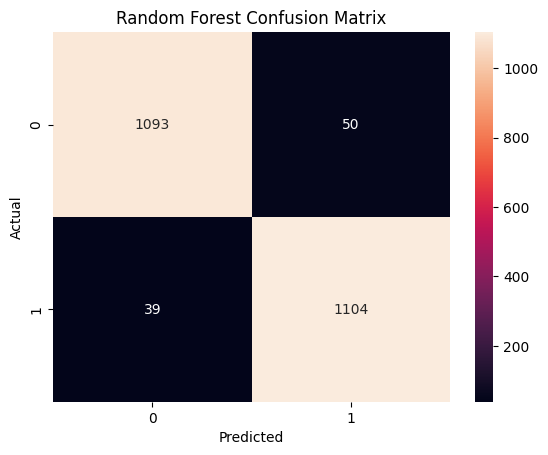


===== SVM =====
              precision    recall  f1-score   support

           0       0.95      0.96      0.95      1143
           1       0.96      0.95      0.95      1143

    accuracy                           0.95      2286
   macro avg       0.95      0.95      0.95      2286
weighted avg       0.95      0.95      0.95      2286



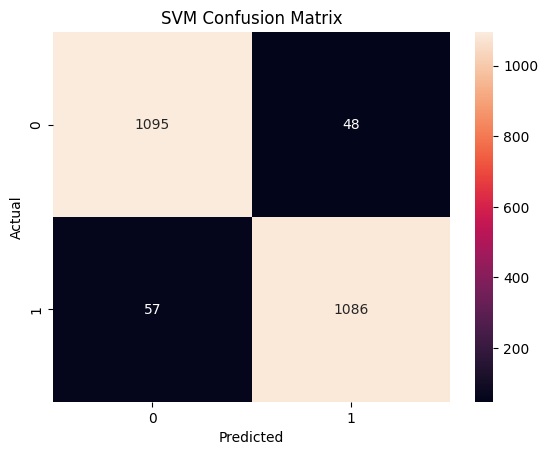

In [8]:
for name, model in models.items():

    if name == "Random Forest":
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:, 1]

    print(f"\n===== {name} =====")
    print(classification_report(y_test, y_pred))

    # store metrics
    f1_scores[name] = f1_score(y_test, y_pred)
    acc_scores[name] = accuracy_score(y_test, y_pred)

    # confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    results[name] = y_prob

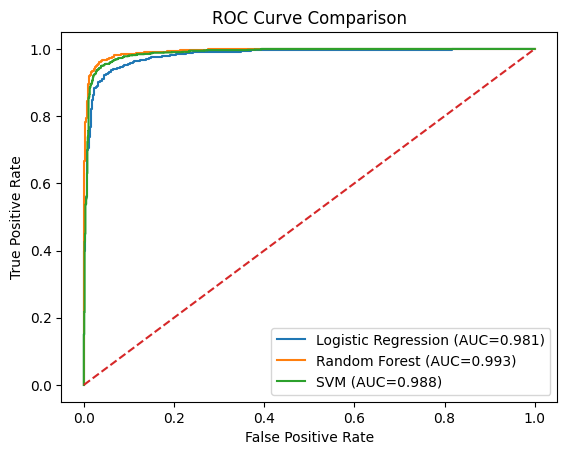

In [9]:
plt.figure()

for name in models.keys():
    probs = results[name]
    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()


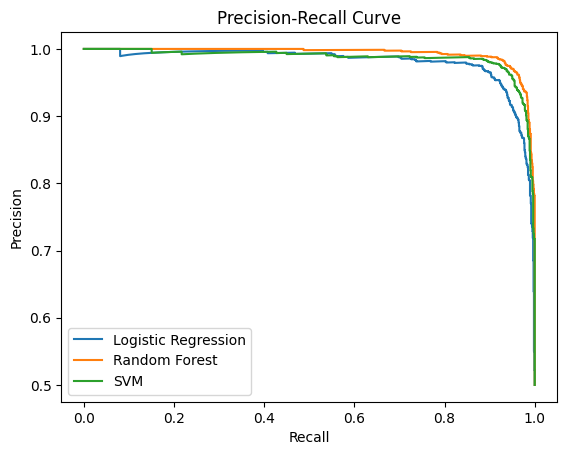

In [10]:
plt.figure()

for name in models.keys():
    probs = results[name]
    precision, recall, _ = precision_recall_curve(y_test, probs)
    plt.plot(recall, precision, label=name)

plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.show()

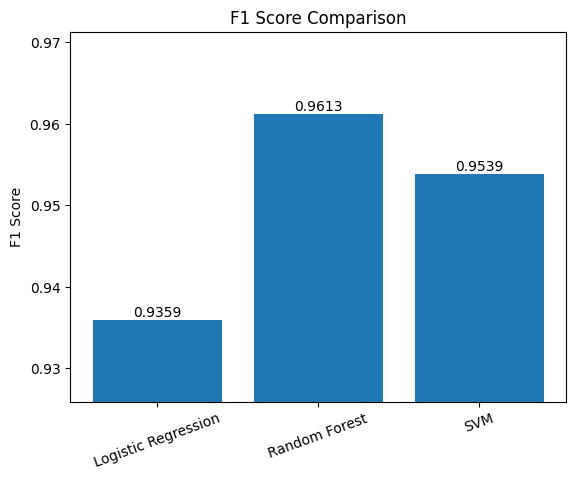

In [15]:
plt.figure()
bars = plt.bar(f1_scores.keys(), f1_scores.values())

plt.title("F1 Score Comparison")
plt.ylabel("F1 Score")

# 🔥 zoom into meaningful range
plt.ylim(min(f1_scores.values()) - 0.01, max(f1_scores.values()) + 0.01)

# 🔥 add value labels
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f"{yval:.4f}",
             ha='center', va='bottom')

plt.xticks(rotation=20)
plt.show()

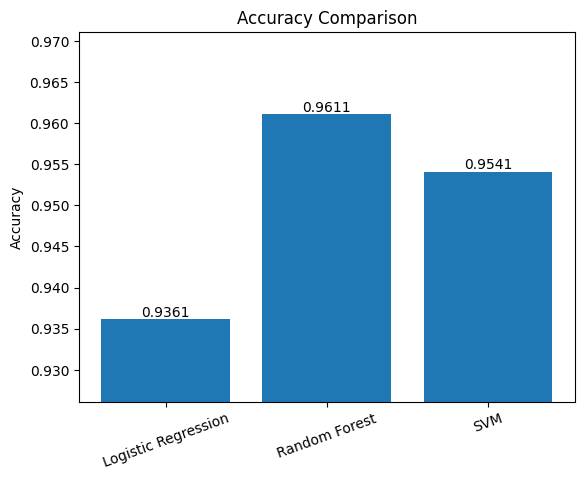

In [16]:
plt.figure()
bars = plt.bar(acc_scores.keys(), acc_scores.values())

plt.title("Accuracy Comparison")
plt.ylabel("Accuracy")

# 🔥 zoom in
plt.ylim(min(acc_scores.values()) - 0.01, max(acc_scores.values()) + 0.01)

# 🔥 value labels
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f"{yval:.4f}",
             ha='center', va='bottom')

plt.xticks(rotation=20)
plt.show()

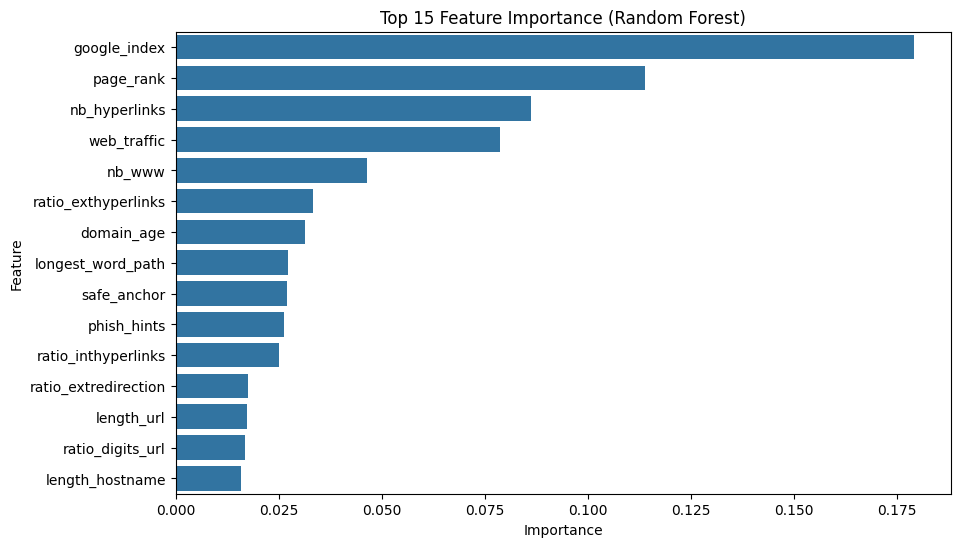

                Feature  Importance
85         google_index    0.178961
86            page_rank    0.113869
56        nb_hyperlinks    0.086241
83          web_traffic    0.078746
20               nb_www    0.046360
58  ratio_exthyperlinks    0.033409
82           domain_age    0.031456
46    longest_word_path    0.027305
74          safe_anchor    0.026923
50          phish_hints    0.026328


In [13]:
rf = models["Random Forest"]

importances = rf.feature_importances_
feat_imp = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    x=feat_imp["Importance"][:15],
    y=feat_imp["Feature"][:15]
)
plt.title("Top 15 Feature Importance (Random Forest)")
plt.show()

print(feat_imp.head(10))

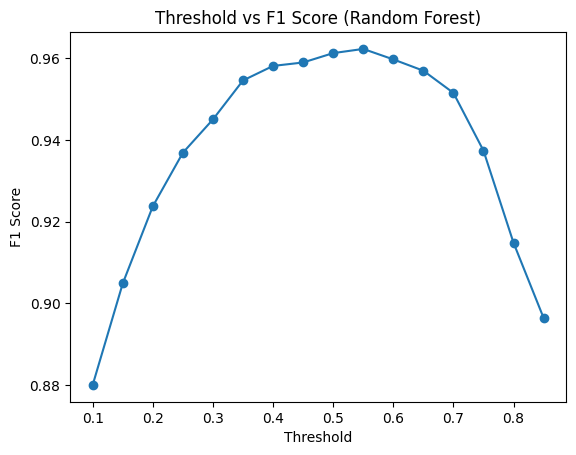

Best threshold: 0.5500000000000002
Best F1: 0.962280701754386


In [14]:
probs = results["Random Forest"]

thresholds = np.arange(0.1, 0.9, 0.05)
f1_list = []

for t in thresholds:
    preds = (probs >= t).astype(int)
    f1_list.append(f1_score(y_test, preds))

plt.figure()
plt.plot(thresholds, f1_list, marker='o')
plt.title("Threshold vs F1 Score (Random Forest)")
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.show()

print("Best threshold:", thresholds[np.argmax(f1_list)])
print("Best F1:", max(f1_list))